## Import Libraries

In [1]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1013b153ef750413e1d7106f6d623df939bbbe5d3bc6f943af95ad19c14e3b3f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.optimizers import Adam
from scipy.stats import gaussian_kde
import os

from tensorflow.keras.models import load_model
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split, TimeSeriesSplit, cross_validate
import shap
from lime import lime_tabular

## Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Part 1: Minneapolis

In [4]:
#  1. Logging Setup for Minneapolis
LOG_FILE_MN = "minneapolis_performance.log"

def log_metrics_mn(message, file_path=LOG_FILE_MN):
    """Appends a message to the log file and prints it to console."""
    print(message)
    with open(file_path, "a") as f:
        f.write(message + "\n")

if os.path.exists(LOG_FILE_MN): os.remove(LOG_FILE_MN)
log_metrics_mn("=== Minneapolis Model Analysis Log ===\n")

# 2. Helper Functions (Shared)

def add_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # Cyclical Month Features
    df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)

    # Lag Features
    df['lag_t2m_1'] = df['t2m'].shift(1)
    df['lag_elec_1'] = df['elecuse'].shift(1)

    return df.dropna()

def prepare_data(df, target_col, feature_cols, look_back=12):
    data = df[feature_cols + [target_col]].values
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    for i in range(len(scaled_data) - look_back):
        X.append(scaled_data[i:(i + look_back), :-1]) # Features
        y.append(scaled_data[i + look_back, -1])      # Target

    X, y = np.array(X), np.array(y)

    # Train/Test Split (80/20)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    test_dates = df['date'].iloc[train_size + look_back : train_size + look_back + len(y_test)]

    return X_train, X_test, y_train, y_test, scaler, test_dates

def build_ffnn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def build_lstm(time_steps, features):
    model = Sequential([
        Input(shape=(time_steps, features)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

# 3. Main Execution Logic (Minneapolis)

def run_minneapolis(file_path):
    city_name = "Minneapolis"
    # Minneapolis features (Includes Humidex)
    base_features = ['t2m', 'd2m', 'solar_rad', 'HUMIDEX_U']

    log_metrics_mn(f"Processing {city_name}...")

    # 1. Load & Prep
    if not os.path.exists(file_path):
        log_metrics_mn(f"CRITICAL ERROR: File not found at {file_path}")
        return

    df_raw = pd.read_pickle(file_path)
    df = add_features(df_raw)
    features = base_features + ['month_sin', 'month_cos', 'lag_t2m_1', 'lag_elec_1']

    X_train_3d, X_test_3d, y_train, y_test, scaler, dates = prepare_data(df, 'elecuse', features)

    # Flatten inputs for SVM & FFNN
    n_samples, n_steps, n_feats = X_train_3d.shape
    X_train_flat = X_train_3d.reshape((n_samples, n_steps * n_feats))
    X_test_flat = X_test_3d.reshape((X_test_3d.shape[0], n_steps * n_feats))

    # Inverse Transform Helper
    def inverse_y(pred):
        dummy = np.zeros((len(pred), len(features) + 1))
        dummy[:, -1] = pred
        return scaler.inverse_transform(dummy)[:, -1]

    y_test_real = inverse_y(y_test)

    # 2. Define Models
    models = {
        "SVM": SVR(kernel='rbf', C=50, gamma='auto', epsilon=0.01),
        "FFNN": build_ffnn(n_steps * n_feats),
        "LSTM": build_lstm(n_steps, n_feats)
    }

    results = {}
    residuals_dict = {}

    # 3. Test Set Evaluation
    log_metrics_mn(f"\n[Test Set Results]")
    for name, model in models.items():
        print(f"Training {name} on full training set...")
        if name == "LSTM":
            model.fit(X_train_3d, y_train, epochs=50, batch_size=16, verbose=0)
            pred = model.predict(X_test_3d).flatten()
        elif name == "FFNN":
            model.fit(X_train_flat, y_train, epochs=50, batch_size=16, verbose=0)
            pred = model.predict(X_test_flat).flatten()
        else:
            model.fit(X_train_flat, y_train)
            pred = model.predict(X_test_flat)

        pred_real = inverse_y(pred)
        results[name] = pred_real
        residuals_dict[name] = y_test_real - pred_real

        # Calculate Metrics
        r2 = r2_score(y_test_real, pred_real)
        mae = mean_absolute_error(y_test_real, pred_real)
        rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
        log_metrics_mn(f"{name: <5} -> R2: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

        # Plot 1: Individual Actual vs Predicted
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=dates, y=y_test_real, mode='lines+markers', name='Actual', line=dict(color='black')))
        fig.add_trace(go.Scatter(x=dates, y=pred_real, mode='lines', name='Predicted', line=dict(color='red', dash='dash')))
        fig.update_layout(title=f"<b>{city_name} - {name}: Actual vs Predicted</b>", template="plotly_white")
        fig.show()

    # Plot 2: Residuals Distribution
    fig_res = go.Figure()
    for name, res in residuals_dict.items():
        kde = gaussian_kde(res)
        x_range = np.linspace(min(res), max(res), 100)
        fig_res.add_trace(go.Scatter(x=x_range, y=kde(x_range), mode='lines', name=f'{name} Residuals', fill='tozeroy'))
    fig_res.update_layout(title=f"<b>{city_name}: Residuals Distribution (Error Density)</b>", xaxis_title="Error (Actual - Pred)", template="plotly_white")
    fig_res.show()

    # 4. Cross-Validation (Generating the Grouped Bar Chart)
    log_metrics_mn(f"\n[Running Cross-Validation for Bar Chart]")
    tscv = TimeSeriesSplit(n_splits=5)

    # Dictionary to store PER FOLD results for the graph
    cv_plot_data = {'Model': [], 'Fold': [], 'MAE': []}

    X_cv = X_train_flat
    y_cv = y_train

    cv_metrics = {name: {'MAE': [], 'RMSE': [], 'R2': []} for name in models.keys()}

    for name in models.keys():
        # Re-build fresh models for CV loop
        if name == "SVM": model_cv = SVR(kernel='rbf', C=50, gamma='auto', epsilon=0.01)
        elif name == "FFNN": model_cv = build_ffnn(X_cv.shape[1])
        elif name == "LSTM": model_cv = build_lstm(n_steps, n_feats)

        fold_num = 1
        for train_idx, val_idx in tscv.split(X_cv):
            xt, xv = X_cv[train_idx], X_cv[val_idx]
            yt, yv = y_cv[train_idx], y_cv[val_idx]

            if name == "LSTM":
                xt = xt.reshape((xt.shape[0], n_steps, n_feats))
                xv = xv.reshape((xv.shape[0], n_steps, n_feats))

            # Train on fold
            if name == "SVM": model_cv.fit(xt, yt); p = model_cv.predict(xv)
            else: model_cv.fit(xt, yt, epochs=30, verbose=0); p = model_cv.predict(xv).flatten()

            yv_real = inverse_y(yv)
            p_real = inverse_y(p)

            # Calculate metrics
            fold_mae = mean_absolute_error(yv_real, p_real)
            mae = mean_absolute_error(yv_real, p_real)
            rmse = np.sqrt(mean_squared_error(yv_real, p_real))
            r2 = r2_score(yv_real, p_real)

            # Store for Plotting
            cv_plot_data['Model'].append(name)
            cv_plot_data['Fold'].append(str(fold_num)) # String for categorical axis
            cv_plot_data['MAE'].append(fold_mae)
            cv_metrics[name]['MAE'].append(mae)
            cv_metrics[name]['RMSE'].append(rmse)
            cv_metrics[name]['R2'].append(r2)

            fold_num += 1

    # 5. Generate the Grouped Bar Chart
    cv_df = pd.DataFrame(cv_plot_data)

    # Custom colors: Blue (SVM), Red/Orange (FFNN), Green (LSTM)
    color_map = {'SVM': '#636EFA', 'FFNN': '#EF553B', 'LSTM': '#00CC96'}

    fig_cv = px.bar(
        cv_df,
        x='Fold',
        y='MAE',
        color='Model',
        barmode='group',
        color_discrete_map=color_map,
        title=f"<b>{city_name}: Cross-Validation MAE per Fold</b>",
        template='plotly_white'
    )

    fig_cv.update_layout(
        yaxis_title="MAE",
        xaxis_title="Fold",
        legend_title="Model",
        hovermode="x unified"
    )
    fig_cv.show()

    # 6. Master Time Series Plot
    fig_master = go.Figure()
    fig_master.add_trace(go.Scatter(x=dates, y=y_test_real, mode='lines+markers', name='Actual', line=dict(color='black', width=3)))

    line_colors = {'SVM': 'blue', 'FFNN': 'red', 'LSTM': 'green'}
    for name, preds in results.items():
        fig_master.add_trace(go.Scatter(x=dates, y=preds, mode='lines', name=name, line=dict(color=line_colors[name])))

    fig_master.update_layout(title=f"<b>{city_name}: Final Comparison (Actual vs Predicted)</b>", template="plotly_white")
    fig_master.show()

# Run Minneapolis
os.chdir('/content/drive/MyDrive/ML Team Project/FFNN_Minnesota_FeatureEng/')
run_minneapolis('FFNN_minnesota_dataframe.pkl')
print(f"Metrics saved to {LOG_FILE_MN}")

=== Minneapolis Model Analysis Log ===

Processing Minneapolis...

[Test Set Results]
Training SVM on full training set...
SVM   -> R2: 0.7914 | MAE: 0.0346 | RMSE: 0.0482


Training FFNN on full training set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
FFNN  -> R2: 0.8751 | MAE: 0.0295 | RMSE: 0.0373


Training LSTM on full training set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
LSTM  -> R2: 0.7462 | MAE: 0.0467 | RMSE: 0.0532



[Running Cross-Validation for Bar Chart]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


Metrics saved to minneapolis_performance.log


### Load in Minneapolis Data & load SHAP, LIME, Correlation Heat Map

In [ ]:
#Set the directory
os.chdir('/content/drive/MyDrive/ML Team Project/FFNN_Minnesota_FeatureEng/')

# Load the trained FFNN model
model = load_model("Minnesota_FFNN_model.keras")

# Load the scalers
scaler_X = joblib.load("scaler_X.pkl")
scaler_y = joblib.load("scaler_y.pkl")

# Load training history
history = joblib.load("ffnn_history.pkl")

# Load your dataframe
df_mn = pd.read_pickle("FFNN_minnesota_dataframe.pkl")

# Load Cross Validation Metrics
cv_metrics = joblib.load("ffnn_cv_metrics.pkl")

Correlation Heat Map

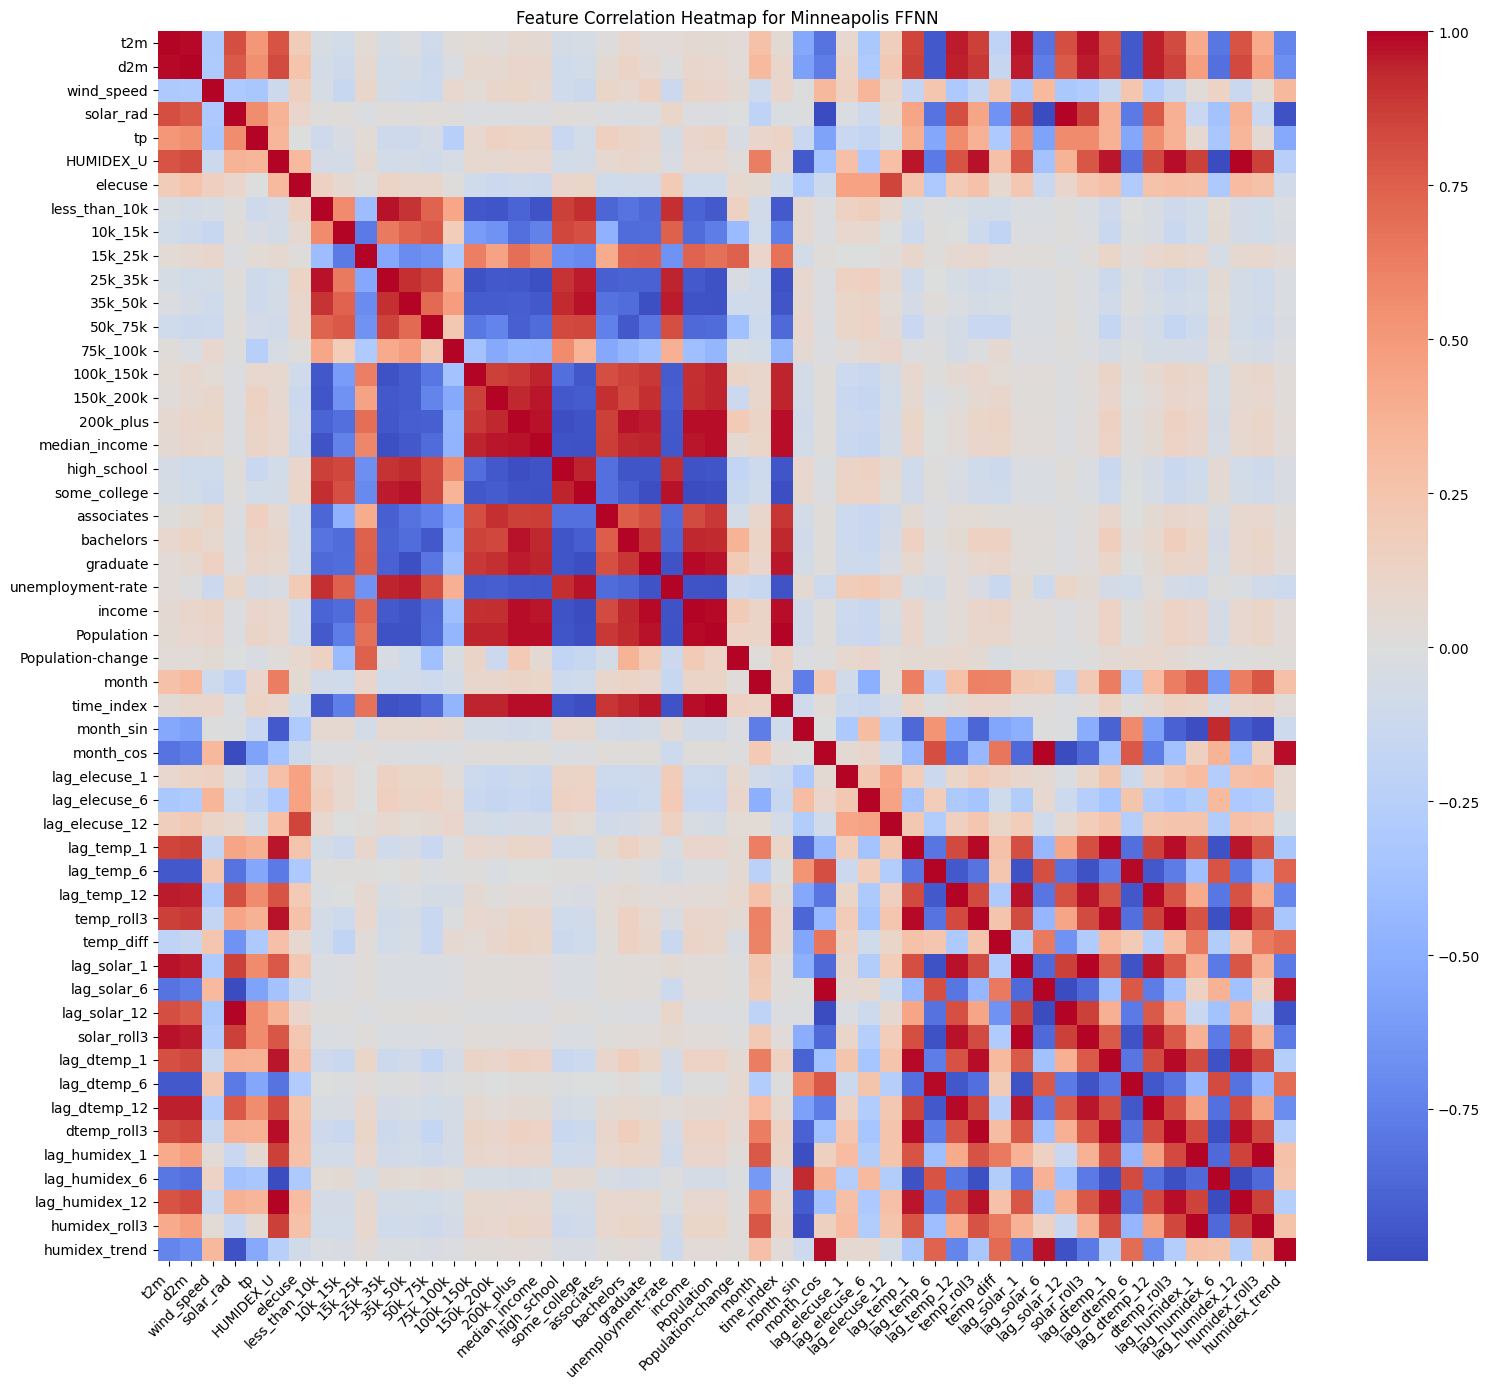

In [ ]:
#Get list of features
feature_names = df_mn.select_dtypes(include=[np.number]).columns.tolist()

# Correlation heatmap of original features
corr_matrix = df_mn[feature_names].corr() #define the correlation
plt.figure(figsize=(16, 14)) #set figure size
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm') #define the colors
plt.xticks(rotation=45, ha='right') #rotate ticks for easier viewing
plt.yticks(rotation=0)
plt.title('Feature Correlation Heatmap for Minneapolis FFNN') #set title
plt.tight_layout()
plt.show()

Correlation Table

In [ ]:
#Correlation Table
feature_cols = [
    # Core meteorology
    't2m', 'd2m', 'solar_rad', 'HUMIDEX_U',

    # Time / seasonality
    'month', 'time_index', 'month_sin', 'month_cos',

    # Electricity lags
    'lag_elecuse_1', 'lag_elecuse_6', 'lag_elecuse_12',

    # Temperature lags + rolling + diff
    'lag_temp_1', 'lag_temp_6', 'lag_temp_12',
    'temp_roll3', 'temp_diff',

    # Solar lags + roll
    'lag_solar_1', 'lag_solar_6', 'lag_solar_12',
    'solar_roll3',

    # Dew point lags + roll
    'lag_dtemp_1', 'lag_dtemp_6', 'lag_dtemp_12',
    'dtemp_roll3',

    # Humidex lags + roll + trend
    'lag_humidex_1', 'lag_humidex_6', 'lag_humidex_12',
    'humidex_roll3', 'humidex_trend'
]

corr_to_target = (
    df_mn[feature_cols + ['elecuse']]
    .corr()['elecuse']
    .drop('elecuse')
    .sort_values(ascending=False)
)

print(corr_to_target)

lag_elecuse_12    0.849284
lag_elecuse_6     0.454922
lag_elecuse_1     0.453824
HUMIDEX_U         0.315903
lag_humidex_12    0.313088
dtemp_roll3       0.288998
lag_dtemp_1       0.279224
humidex_roll3     0.270167
temp_roll3        0.267797
lag_humidex_1     0.266640
lag_dtemp_12      0.261370
d2m               0.257210
lag_temp_1        0.253475
solar_roll3       0.229259
lag_solar_1       0.229030
lag_temp_12       0.209292
t2m               0.196165
lag_solar_12      0.100304
solar_rad         0.099969
temp_diff         0.072825
month             0.048079
humidex_trend    -0.087157
time_index       -0.099370
month_cos        -0.122022
lag_solar_6      -0.132605
lag_dtemp_6      -0.289115
month_sin        -0.295560
lag_humidex_6    -0.310854
lag_temp_6       -0.314745
Name: elecuse, dtype: float64


SHAP

In [ ]:
X = df_mn[feature_cols].values #input
y = df_mn['elecuse'].values #target
features = df_mn.drop(columns=['elecuse']).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) #split the same way

X_test_scaled = scaler_X.transform(X_test)  # apply to test data, dont refit
X_train_scaled = scaler_X.transform(X_train)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))  # apply to test date, dont refit and make 2D array
y_pred_scaled = model.predict(X_test_scaled) #predict on scaled features
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # convert back to original electricity units

feature_names = feature_cols
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

#Use background sample safely
n_samples = min(100, len(X_train_df))
background = X_train_df.sample(n_samples, random_state=0)

#KernelExplainer
explainer = shap.KernelExplainer(model.predict, background)
shap_values = explainer.shap_values(X_test_df)

#Convert SHAP output to array
shap_values = np.array(shap_values)

#Feature importance
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
normalized_shap = mean_abs_shap / mean_abs_shap.sum()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
5002/5002 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

SHAP Features Ranked

In [ ]:
mean_abs_shap = mean_abs_shap.flatten()
normalized_shap = normalized_shap.flatten()

#Create DataFrame
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean|SHAP|': mean_abs_shap,
    'Normalized|SHAP|': normalized_shap
}).sort_values(by='Mean|SHAP|', ascending=False)

#print(shap_importance_df)

Bar Plot of Normalized Sorted SHAP

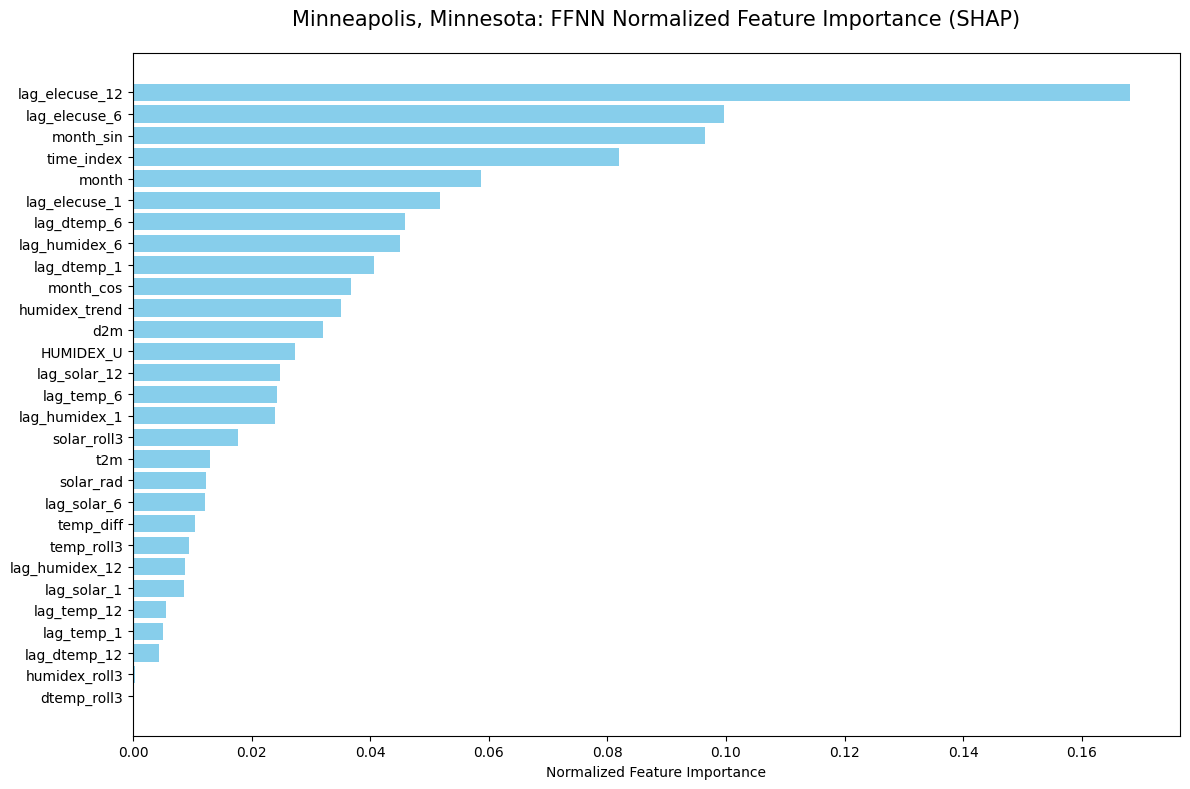

In [ ]:
#Make bar plot for SHAP
plt.figure(figsize=(12, 8))
plt.barh(
    shap_importance_df['Feature'][::-1],
    shap_importance_df['Normalized|SHAP|'][::-1],
    color='skyblue'
)
plt.xlabel("Normalized Feature Importance")
plt.title("Minneapolis, Minnesota: FFNN Normalized Feature Importance (SHAP)", fontsize=15, pad=20)
plt.tight_layout()
plt.show()

LIME

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


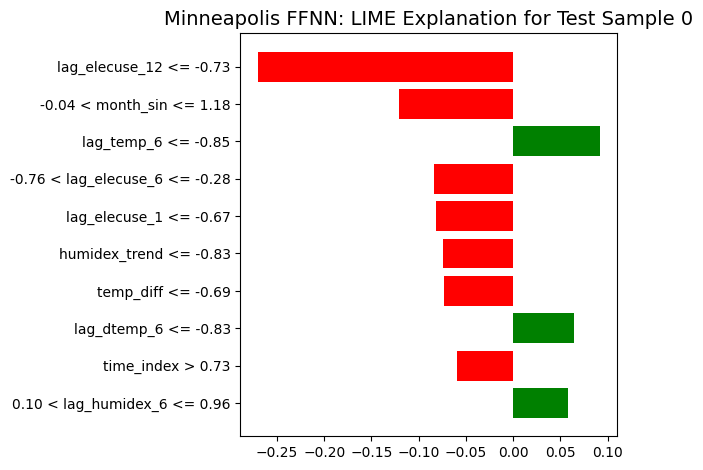

Top features influencing this prediction:
lag_elecuse_12 <= -0.73: -0.2706
-0.04 < month_sin <= 1.18: -0.1212
lag_temp_6 <= -0.85: 0.0919
-0.76 < lag_elecuse_6 <= -0.28: -0.0835
lag_elecuse_1 <= -0.67: -0.0818
humidex_trend <= -0.83: -0.0745
temp_diff <= -0.69: -0.0730
lag_dtemp_6 <= -0.83: 0.0646
time_index > 0.73: -0.0590
0.10 < lag_humidex_6 <= 0.96: 0.0583


In [ ]:
#Use scaled training data (same as model input)
X_train_lime = X_train_scaled      # shape (num_train_samples, num_features)
X_test_lime  = X_test_scaled       # shape (num_test_samples, num_features)
feature_names = feature_cols       # list of 29 feature names

#Create LIME explainer
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    mode='regression'
)

#Select a sample to explain
sample_index = 0                    #first test sample; change as needed
sample = X_test_lime[sample_index]  #single row

#Explain the prediction
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=model.predict,
    num_features=10                #top 10 contributing features
)

#Plot the explanation
fig = exp.as_pyplot_figure()
plt.title(f"Minneapolis FFNN: LIME Explanation for Test Sample {sample_index}", fontsize=14)
plt.tight_layout()
plt.show()

#Print the feature contributions in text
print("Top features influencing this prediction:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

## Part 2: Phoenix

In [ ]:
# 1. Logging Setup for Phoenix
LOG_FILE_PHX = "phoenix_performance.log"

def log_metrics_phx(message, file_path=LOG_FILE_PHX):
    print(message)
    with open(file_path, "a") as f:
        f.write(message + "\n")

# Clear existing log file
if os.path.exists(LOG_FILE_PHX):
    os.remove(LOG_FILE_PHX)
log_metrics_phx("=== Phoenix Model Analysis Log ===\n")

# 2. Main Execution Logic

def run_phoenix(file_path):
    city_name = "Phoenix"
    # Phoenix specific features (No Humidex)
    base_features = ['t2m', 'd2m', 'solar_rad']

    log_metrics_phx(f"Processing {city_name}...")

    # 1. Load & Prep
    if not os.path.exists(file_path):
        log_metrics_phx(f"CRITICAL ERROR: File not found at {file_path}")
        return

    df_raw = pd.read_pickle(file_path)
    df = add_features(df_raw) # Uses the function from Part 1

    # Add engineered features
    features = base_features + ['month_sin', 'month_cos', 'lag_t2m_1', 'lag_elec_1']

    X_train_3d, X_test_3d, y_train, y_test, scaler, dates = prepare_data(df, 'elecuse', features)

    # Flatten inputs for SVM & FFNN
    n_samples, n_steps, n_feats = X_train_3d.shape
    X_train_flat = X_train_3d.reshape((n_samples, n_steps * n_feats))
    X_test_flat = X_test_3d.reshape((X_test_3d.shape[0], n_steps * n_feats))

    # Inverse Transform Helper
    def inverse_y(pred):
        dummy = np.zeros((len(pred), len(features) + 1))
        dummy[:, -1] = pred
        return scaler.inverse_transform(dummy)[:, -1]

    y_test_real = inverse_y(y_test)

    # 2. Define Models
    models = {
        "SVM": SVR(kernel='rbf', C=50, gamma='auto', epsilon=0.01),
        "FFNN": build_ffnn(n_steps * n_feats),
        "LSTM": build_lstm(n_steps, n_feats)
    }

    results = {}
    residuals_dict = {}

    # 3. Train & Final Test Evaluation
    log_metrics_phx(f"\n[Final Test Set Results]")

    for name, model in models.items():
        print(f"Training {name} on full training set...")

        # Train
        if name == "LSTM":
            model.fit(X_train_3d, y_train, epochs=50, batch_size=16, verbose=0)
            pred = model.predict(X_test_3d).flatten()
        elif name == "FFNN":
            model.fit(X_train_flat, y_train, epochs=50, batch_size=16, verbose=0)
            pred = model.predict(X_test_flat).flatten()
        else: # SVM
            model.fit(X_train_flat, y_train)
            pred = model.predict(X_test_flat)

        # Inverse
        pred_real = inverse_y(pred)
        results[name] = pred_real
        residuals_dict[name] = y_test_real - pred_real

        # Metrics
        r2 = r2_score(y_test_real, pred_real)
        mae = mean_absolute_error(y_test_real, pred_real)
        rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
        log_metrics_phx(f"{name: <5} -> R2: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

        # Plot 1: Individual Actual vs Predicted
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=dates, y=y_test_real, mode='lines+markers', name='Actual', line=dict(color='black')))
        fig.add_trace(go.Scatter(x=dates, y=pred_real, mode='lines', name='Predicted', line=dict(color='red', dash='dash')))
        fig.update_layout(title=f"{city_name} - {name}: Actual vs Predicted", template="plotly_white")
        fig.show()

    # Plot 2: Residuals Distribution
    fig_res = go.Figure()
    for name, res in residuals_dict.items():
        kde = gaussian_kde(res)
        x_range = np.linspace(min(res), max(res), 100)
        fig_res.add_trace(go.Scatter(x=x_range, y=kde(x_range), mode='lines', name=f'{name} Residuals', fill='tozeroy'))
    fig_res.update_layout(title=f"{city_name}: Residuals Distribution (Error Density)", xaxis_title="Error (Actual - Pred)", template="plotly_white")
    fig_res.show()

    # 4. Cross-Validation (Generating the Grouped Bar Chart)
    log_metrics_phx(f"\n[Running Cross-Validation for Bar Chart]")
    tscv = TimeSeriesSplit(n_splits=3)

    # Dictionary to store PER FOLD results for the graph
    cv_plot_data = {'Model': [], 'Fold': [], 'MAE': []}

    X_cv = X_train_flat
    y_cv = y_train

    for name in models.keys():
        # Re-build fresh models for CV loop so we don't cheat with trained weights
        if name == "SVM": model_cv = SVR(kernel='rbf', C=50, gamma='auto', epsilon=0.01)
        elif name == "FFNN": model_cv = build_ffnn(X_cv.shape[1])
        elif name == "LSTM": model_cv = build_lstm(n_steps, n_feats)

        fold_num = 1
        for train_idx, val_idx in tscv.split(X_cv):
            xt, xv = X_cv[train_idx], X_cv[val_idx]
            yt, yv = y_cv[train_idx], y_cv[val_idx]

            # Reshape for LSTM
            if name == "LSTM":
                xt = xt.reshape((xt.shape[0], n_steps, n_feats))
                xv = xv.reshape((xv.shape[0], n_steps, n_feats))

            # Train on fold
            if name == "SVM": model_cv.fit(xt, yt); p = model_cv.predict(xv)
            else: model_cv.fit(xt, yt, epochs=30, verbose=0); p = model_cv.predict(xv).flatten()

            # Inverse
            yv_real = inverse_y(yv)
            p_real = inverse_y(p)

            # Calculate MAE for this specific fold
            fold_mae = mean_absolute_error(yv_real, p_real)

            # Store for Plotting
            cv_plot_data['Model'].append(name)
            cv_plot_data['Fold'].append(str(fold_num)) # String ensures categorical axis
            cv_plot_data['MAE'].append(fold_mae)

            fold_num += 1

    # Plot 3: Cross-Validation Grouped Bar Chart
    cv_df = pd.DataFrame(cv_plot_data)

    # Colors: Blue (SVM), Red/Orange (FFNN), Green (LSTM)
    color_map = {'SVM': '#636EFA', 'FFNN': '#EF553B', 'LSTM': '#00CC96'}

    fig_cv = px.bar(
        cv_df,
        x='Fold',
        y='MAE',
        color='Model',
        barmode='group',
        color_discrete_map=color_map,
        title=f"<b>{city_name}: Cross-Validation MAE per Fold</b>",
        template='plotly_white'
    )

    fig_cv.update_layout(
        yaxis_title="MAE (Mean Absolute Error)",
        xaxis_title="Fold Number",
        legend_title="Model",
        hovermode="x unified"
    )
    fig_cv.show()

    # Plot 4: Master Time Series Comparison
    fig_master = go.Figure()
    fig_master.add_trace(go.Scatter(x=dates, y=y_test_real, mode='lines+markers', name='Actual', line=dict(color='black', width=3)))

    line_colors = {'SVM': 'blue', 'FFNN': 'red', 'LSTM': 'green'}
    for name, preds in results.items():
        fig_master.add_trace(go.Scatter(x=dates, y=preds, mode='lines', name=name, line=dict(color=line_colors[name])))

    fig_master.update_layout(title=f"<b>{city_name}: Final Comparison (Actual vs Predicted)</b>", template="plotly_white")
    fig_master.show()

# Run Phoenix
os.chdir('/content/drive/MyDrive/ML Team Project/FFNN_Arizona_FeatureEng/')
run_phoenix('FFNN_arizona_dataframe.pkl')
print(f"Metrics saved to {LOG_FILE_PHX}")

=== Phoenix Model Analysis Log ===

Processing Phoenix...

[Final Test Set Results]
Training SVM on full training set...
SVM   -> R2: 0.9095 | MAE: 0.0962 | RMSE: 0.1150


Training FFNN on full training set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
FFNN  -> R2: 0.9395 | MAE: 0.0783 | RMSE: 0.0941


Training LSTM on full training set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
LSTM  -> R2: 0.9615 | MAE: 0.0581 | RMSE: 0.0750



[Running Cross-Validation for Bar Chart]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


Metrics saved to phoenix_performance.log


### Load in Phoenix Data & load SHAP, LIME, Correlation Heat Map

In [ ]:
# Load the trained FFNN model
model = load_model("Arizona_FFNN_model.keras")

# Load the scalers
scaler_X = joblib.load("scaler_X.pkl")
scaler_y = joblib.load("scaler_y.pkl")

# Load training history
history = joblib.load("ffnn_history.pkl")

# Load your dataframe
df_az = pd.read_pickle("FFNN_arizona_dataframe.pkl")

# Load Cross Validation Metrics
cv_metrics = joblib.load("ffnn_cv_metrics.pkl")

Correlation Heat Map

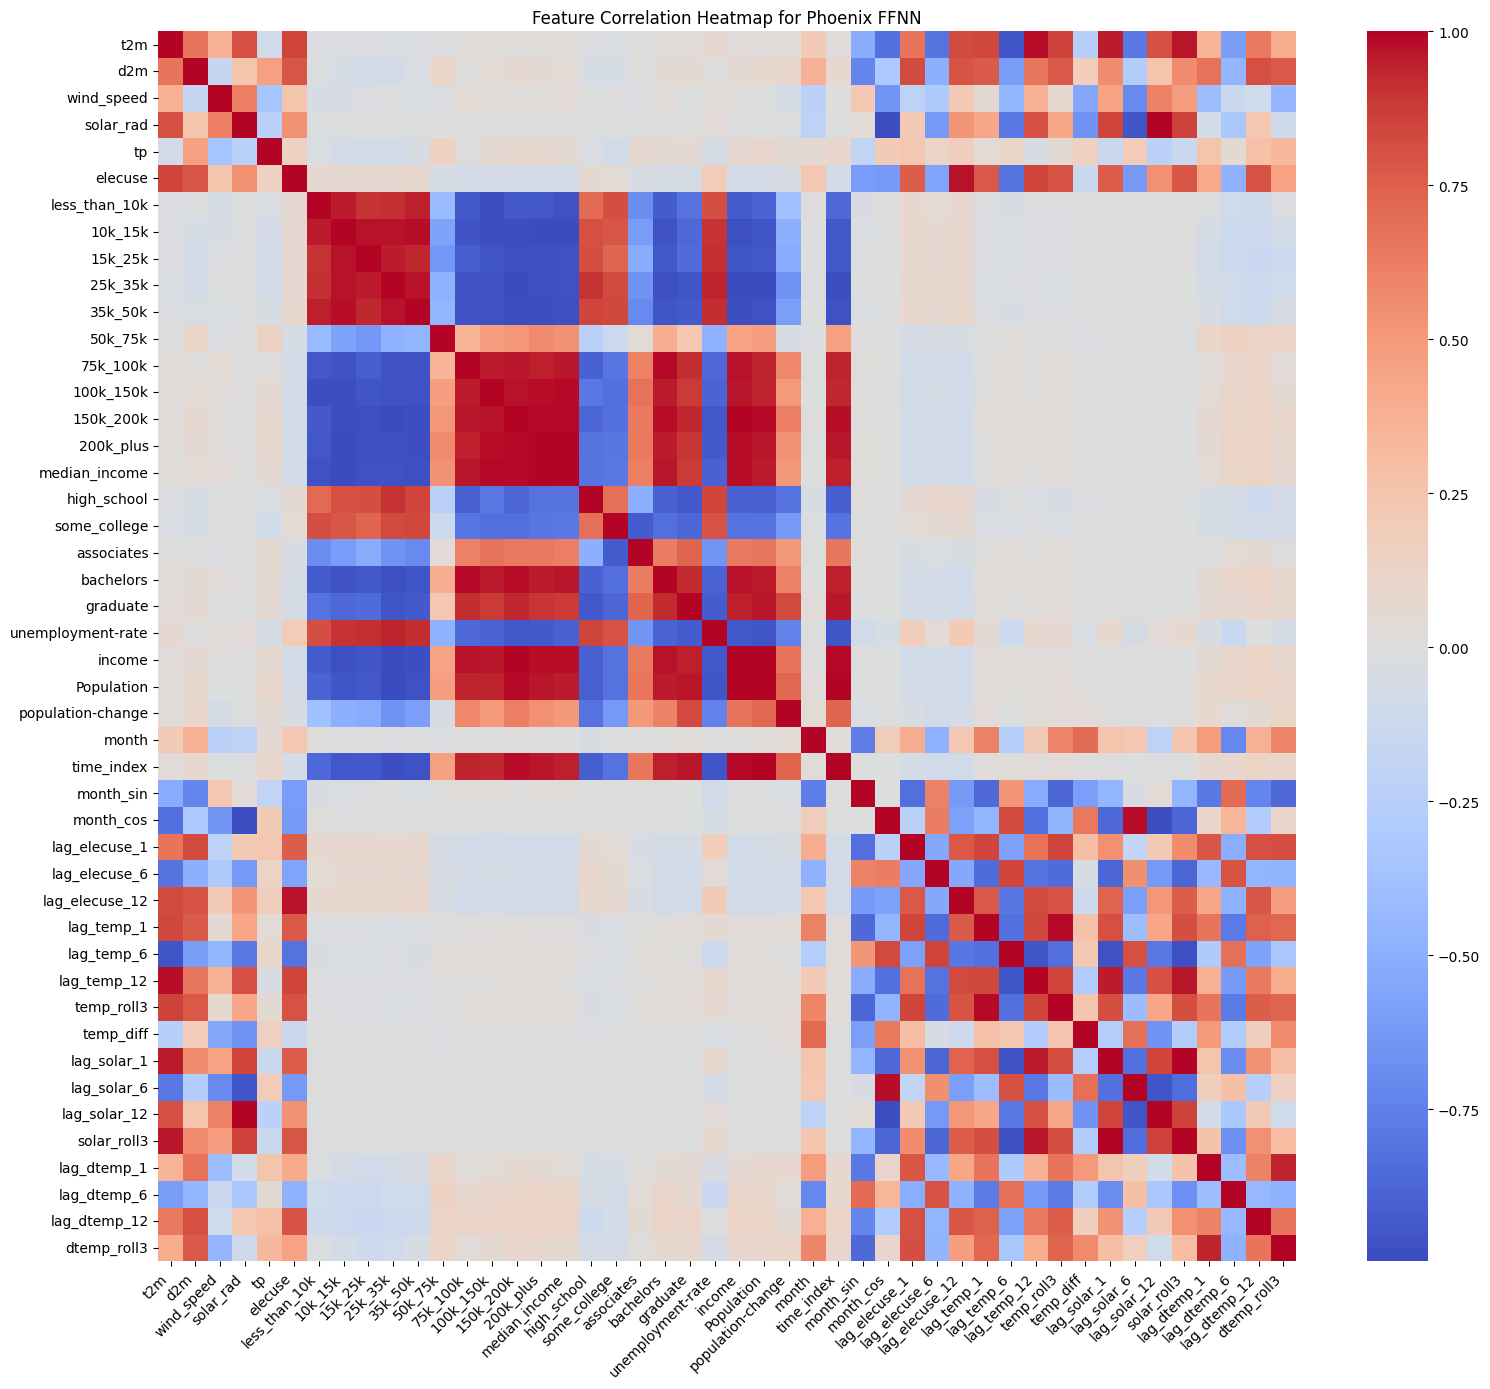

In [ ]:
#Get list of features
feature_names = df_az.select_dtypes(include=[np.number]).columns.tolist()

# Correlation heatmap of original features
corr_matrix = df_az[feature_names].corr() #define the correlation
plt.figure(figsize=(16, 14)) #set figure size
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm') #define the colors
plt.xticks(rotation=45, ha='right') #rotate ticks for easier viewing
plt.yticks(rotation=0)
plt.title('Feature Correlation Heatmap for Phoenix FFNN') #set title
plt.tight_layout()
plt.show()

Correlation Table

In [ ]:
feature_cols = [
    # Core meteorology
    't2m', 'd2m', 'solar_rad',

    # Time / seasonality
    'month', 'time_index', 'month_sin', 'month_cos',

    # Electricity lags
    'lag_elecuse_1', 'lag_elecuse_6', 'lag_elecuse_12',

    # Temperature lags + rolling + diff
    'lag_temp_1', 'lag_temp_6', 'lag_temp_12',
    'temp_roll3', 'temp_diff',

    # Solar lags + roll
    'lag_solar_1', 'lag_solar_6', 'lag_solar_12',
    'solar_roll3',

    # Dew point lags + roll
    'lag_dtemp_1', 'lag_dtemp_6', 'lag_dtemp_12',
    'dtemp_roll3',
]

X = df_az[feature_cols].values #input
y = df_az['elecuse'].values #target
features = df_az.drop(columns=['elecuse']).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) #split the same way

X_test_scaled = scaler_X.transform(X_test)  # apply to test data, dont refit
X_train_scaled = scaler_X.transform(X_train)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))  # apply to test date, dont refit and make 2D array
y_pred_scaled = model.predict(X_test_scaled) #predict on scaled features
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # convert back to original electricity units

#Correlation Table

corr_to_target = (
    df_az[feature_cols + ['elecuse']]
    .corr()['elecuse']
    .drop('elecuse')
    .sort_values(ascending=False)
)

print(corr_to_target)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
lag_elecuse_12    0.974902
t2m               0.848540
lag_temp_12       0.845117
temp_roll3        0.797574
lag_dtemp_12      0.790254
d2m               0.785090
solar_roll3       0.784122
lag_temp_1        0.774485
lag_solar_1       0.762215
lag_elecuse_1     0.758273
solar_rad         0.546784
lag_solar_12      0.541679
dtemp_roll3       0.454220
lag_dtemp_1       0.416568
month             0.234079
time_index       -0.066444
temp_diff        -0.134330
lag_dtemp_6      -0.489735
lag_elecuse_6    -0.561267
month_sin        -0.609282
month_cos        -0.622351
lag_solar_6      -0.629993
lag_temp_6       -0.822388
Name: elecuse, dtype: float64


SHAP

In [ ]:
feature_names = feature_cols
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

#Use background sample safely
n_samples = min(100, len(X_train_df))
background = X_train_df.sample(n_samples, random_state=0)

#KernelExplainer
explainer = shap.KernelExplainer(model.predict, background)
shap_values = explainer.shap_values(X_test_df)

#Convert SHAP output to array
shap_values = np.array(shap_values)

#Feature importance
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
normalized_shap = mean_abs_shap / mean_abs_shap.sum()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


  0%|          | 0/23 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
5955/5955 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

SHAP Features Ranked

In [ ]:
#Make sure 1D
mean_abs_shap = mean_abs_shap.flatten()
normalized_shap = normalized_shap.flatten()

#Create DataFrame
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean|SHAP|': mean_abs_shap,
    'Normalized|SHAP|': normalized_shap
}).sort_values(by='Mean|SHAP|', ascending=False)

#print(shap_importance_df)

Bar Plot of Normalized SHAP

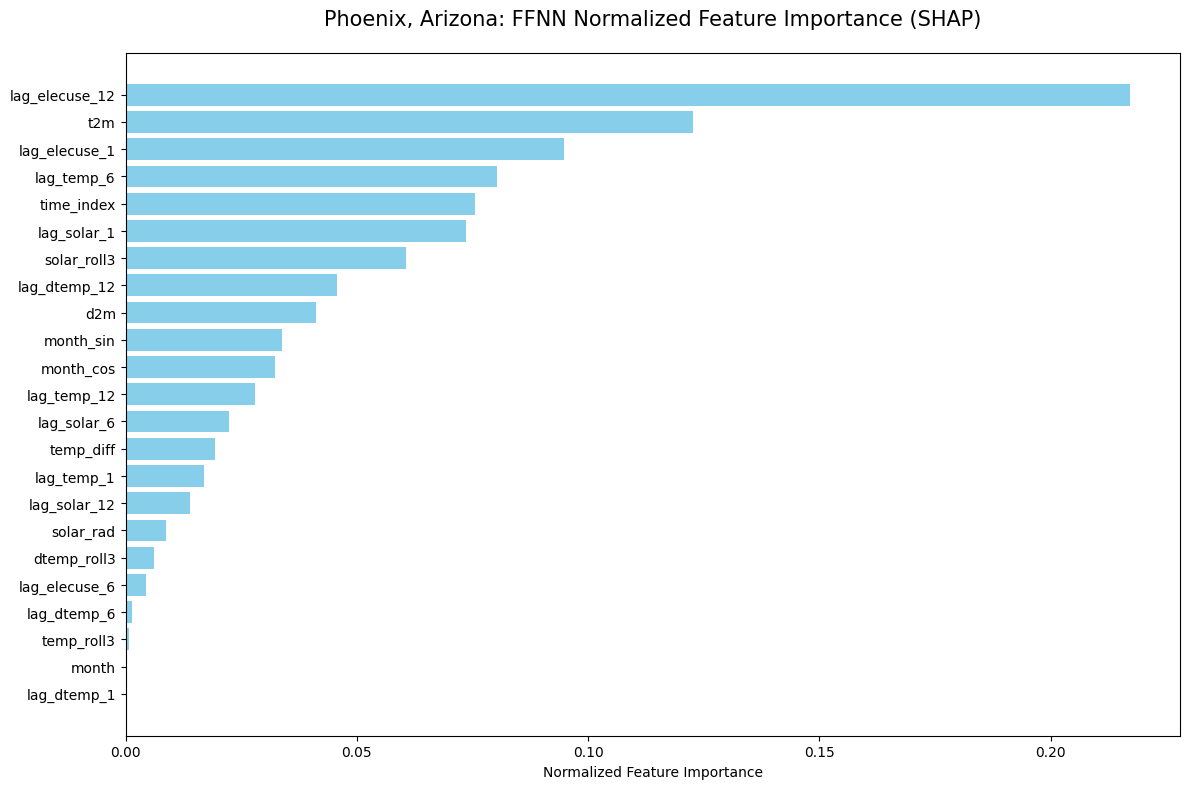

In [ ]:
#Make bar plot for SHAP
plt.figure(figsize=(12, 8))
plt.barh(
    shap_importance_df['Feature'][::-1],
    shap_importance_df['Normalized|SHAP|'][::-1],
    color='skyblue'
)
plt.xlabel("Normalized Feature Importance")
plt.title("Phoenix, Arizona: FFNN Normalized Feature Importance (SHAP)", fontsize=15, pad=20)
plt.tight_layout()
plt.show()

LIME

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


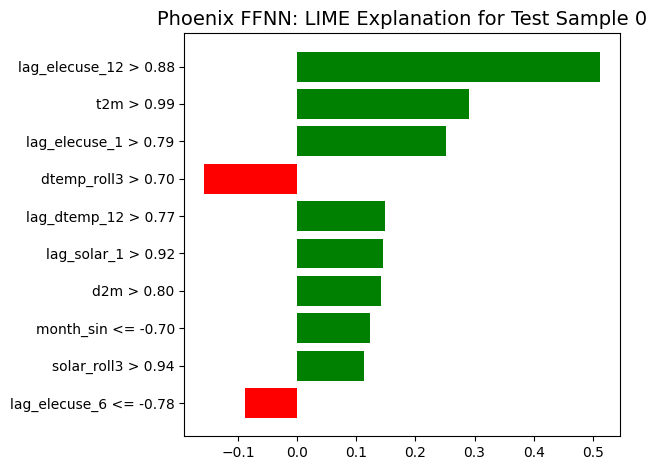

Top features influencing this prediction:
lag_elecuse_12 > 0.88: 0.5126
t2m > 0.99: 0.2902
lag_elecuse_1 > 0.79: 0.2518
dtemp_roll3 > 0.70: -0.1574
lag_dtemp_12 > 0.77: 0.1484
lag_solar_1 > 0.92: 0.1445
d2m > 0.80: 0.1425
month_sin <= -0.70: 0.1236
solar_roll3 > 0.94: 0.1125
lag_elecuse_6 <= -0.78: -0.0891


In [ ]:
#Use scaled training data (same as model input)
X_train_lime = X_train_scaled      # shape (num_train_samples, num_features)
X_test_lime  = X_test_scaled       # shape (num_test_samples, num_features)
feature_names = feature_cols       # list of feature names

#Create LIME explainer
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    mode='regression'
)

#Select a sample to explain
sample_index = 0                    #first test sample; change as needed
sample = X_test_lime[sample_index]  #single row

#Explain the prediction
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=model.predict,
    num_features=10                #top 10 contributing features
)

#Plot the explanation
fig = exp.as_pyplot_figure()
plt.title(f"Phoenix FFNN: LIME Explanation for Test Sample {sample_index}", fontsize=14)
plt.tight_layout()
plt.show()

#Print the feature contributions in text
print("Top features influencing this prediction:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")